## CLEANING AND PREPROCESSING

In [65]:
import pandas as pd
import numpy as np
import re
from langdetect import detect
from textblob import TextBlob
import nltk
import unicodedata
import matplotlib.pyplot as plt

In [66]:
dff=pd.read_json("raw_reviews.json")
dff.to_csv("raw_reviews.csv")
print(dff.head())

  bank                    app_id                             review_id  \
0  BOA  com.boa.boaMobileBanking  d3f86858-3448-43ea-b583-206e07028ec2   
1  BOA  com.boa.boaMobileBanking  f1db2116-2cd4-4706-a634-e5a9c6a3b8f6   
2  BOA  com.boa.boaMobileBanking  475f9227-bddf-4e35-bc04-ea4ae6ad8bf5   
3  BOA  com.boa.boaMobileBanking  6f88a64c-ca26-4c95-9f18-d2ede6aebae9   
4  BOA  com.boa.boaMobileBanking  946d521b-c37a-48d0-a767-d5b52518b1f6   

          user_name  score                                            content  \
0      mesfin seifu      5                                           Niec app   
1  IMRAN Abdulhakim      5                               best app of the year   
2           Bat Man      2                                                waw   
3       Selam Haile      1  it constantly bugs and doesnt open what is the...   
4  Shewayref Negash      5                                            good sp   

                              date  thumbs_up  
0 2025-12-12 11:00:0

In [67]:
dff.head()

,bank,app_id,review_id,user_name,score,content,date,thumbs_up
0,BOA,com.boa.boaMobileBanking,d3f86858-3448-43ea-b583-206e07028ec2,mesfin seifu,5,Niec app,2025-12-12 11:00:05.377000+00:00,0
1,BOA,com.boa.boaMobileBanking,f1db2116-2cd4-4706-a634-e5a9c6a3b8f6,IMRAN Abdulhakim,5,best app of the year,2025-12-12 09:37:25.400000+00:00,0
2,BOA,com.boa.boaMobileBanking,475f9227-bddf-4e35-bc04-ea4ae6ad8bf5,Bat Man,2,waw,2025-12-12 08:40:45.641000+00:00,0
3,BOA,com.boa.boaMobileBanking,6f88a64c-ca26-4c95-9f18-d2ede6aebae9,Selam Haile,1,it constantly bugs and doesnt open what is the...,2025-12-12 07:56:13.982000+00:00,0
4,BOA,com.boa.boaMobileBanking,946d521b-c37a-48d0-a767-d5b52518b1f6,Shewayref Negash,5,good sp,2025-12-10 19:32:27.537000+00:00,0


In [68]:
dff.describe()

,score,thumbs_up
count,600.000000,600.000000
mean,3.866667,6.893333
std,1.665386,47.467679
min,1.000000,0.000000
25%,2.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,811.000000


In [69]:
dff.info

<bound method DataFrame.info of        bank                     app_id                             review_id  \
0       BOA   com.boa.boaMobileBanking  d3f86858-3448-43ea-b583-206e07028ec2   
1       BOA   com.boa.boaMobileBanking  f1db2116-2cd4-4706-a634-e5a9c6a3b8f6   
2       BOA   com.boa.boaMobileBanking  475f9227-bddf-4e35-bc04-ea4ae6ad8bf5   
3       BOA   com.boa.boaMobileBanking  6f88a64c-ca26-4c95-9f18-d2ede6aebae9   
4       BOA   com.boa.boaMobileBanking  946d521b-c37a-48d0-a767-d5b52518b1f6   
..      ...                        ...                                   ...   
595  Dashen  com.dashen.dashensuperapp  90dfd168-3d83-4e21-87ee-6500a304e586   
596  Dashen  com.dashen.dashensuperapp  24c09146-a504-429e-a1fe-9ffb57e044ad   
597  Dashen  com.dashen.dashensuperapp  f3297b4d-0fc8-4221-9daf-4bbe7022c8f1   
598  Dashen  com.dashen.dashensuperapp  32f7f582-e0e2-4127-b460-8faa11fc3ba1   
599  Dashen  com.dashen.dashensuperapp  a508c79d-95b9-4133-a32b-095e1bf3c75c   

       

In [70]:
dff.isnull().sum()

bank         0
app_id       0
review_id    0
user_name    0
score        0
content      0
date         0
thumbs_up    0
dtype: int64

In [71]:
dff

,bank,app_id,review_id,user_name,score,content,date,thumbs_up
0,BOA,com.boa.boaMobileBanking,d3f86858-3448-43ea-b583-206e07028ec2,mesfin seifu,5,Niec app,2025-12-12 11:00:05.377000+00:00,0
1,BOA,com.boa.boaMobileBanking,f1db2116-2cd4-4706-a634-e5a9c6a3b8f6,IMRAN Abdulhakim,5,best app of the year,2025-12-12 09:37:25.400000+00:00,0
2,BOA,com.boa.boaMobileBanking,475f9227-bddf-4e35-bc04-ea4ae6ad8bf5,Bat Man,2,waw,2025-12-12 08:40:45.641000+00:00,0
3,BOA,com.boa.boaMobileBanking,6f88a64c-ca26-4c95-9f18-d2ede6aebae9,Selam Haile,1,it constantly bugs and doesnt open what is the...,2025-12-12 07:56:13.982000+00:00,0
4,BOA,com.boa.boaMobileBanking,946d521b-c37a-48d0-a767-d5b52518b1f6,Shewayref Negash,5,good sp,2025-12-10 19:32:27.537000+00:00,0
...,...,...,...,...,...,...,...,...
595,Dashen,com.dashen.dashensuperapp,90dfd168-3d83-4e21-87ee-6500a304e586,Kelbesa Gonfa,5,App That makes cashless society in our century...,2025-09-27 12:05:30.600000+00:00,1
596,Dashen,com.dashen.dashensuperapp,24c09146-a504-429e-a1fe-9ffb57e044ad,Tade Bikila,1,tadass,2025-09-27 11:52:55.885000+00:00,0
597,Dashen,com.dashen.dashensuperapp,f3297b4d-0fc8-4221-9daf-4bbe7022c8f1,Muhajir Redwan,1,ሙሃጂራ,2025-09-27 10:27:18.574000+00:00,0
598,Dashen,com.dashen.dashensuperapp,32f7f582-e0e2-4127-b460-8faa11fc3ba1,Melkamu Tamir,5,It is an amazing app and all in one,2025-09-27 10:15:35.658000+00:00,0


In [72]:
def normalize_text(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKD", s)
    s = s.strip()
    s = s.replace("\n", "").replace("\r", "")
    s = re.sub(r"\s+", " ", s)
    return s

In [73]:
dff

,bank,app_id,review_id,user_name,score,content,date,thumbs_up
0,BOA,com.boa.boaMobileBanking,d3f86858-3448-43ea-b583-206e07028ec2,mesfin seifu,5,Niec app,2025-12-12 11:00:05.377000+00:00,0
1,BOA,com.boa.boaMobileBanking,f1db2116-2cd4-4706-a634-e5a9c6a3b8f6,IMRAN Abdulhakim,5,best app of the year,2025-12-12 09:37:25.400000+00:00,0
2,BOA,com.boa.boaMobileBanking,475f9227-bddf-4e35-bc04-ea4ae6ad8bf5,Bat Man,2,waw,2025-12-12 08:40:45.641000+00:00,0
3,BOA,com.boa.boaMobileBanking,6f88a64c-ca26-4c95-9f18-d2ede6aebae9,Selam Haile,1,it constantly bugs and doesnt open what is the...,2025-12-12 07:56:13.982000+00:00,0
4,BOA,com.boa.boaMobileBanking,946d521b-c37a-48d0-a767-d5b52518b1f6,Shewayref Negash,5,good sp,2025-12-10 19:32:27.537000+00:00,0
...,...,...,...,...,...,...,...,...
595,Dashen,com.dashen.dashensuperapp,90dfd168-3d83-4e21-87ee-6500a304e586,Kelbesa Gonfa,5,App That makes cashless society in our century...,2025-09-27 12:05:30.600000+00:00,1
596,Dashen,com.dashen.dashensuperapp,24c09146-a504-429e-a1fe-9ffb57e044ad,Tade Bikila,1,tadass,2025-09-27 11:52:55.885000+00:00,0
597,Dashen,com.dashen.dashensuperapp,f3297b4d-0fc8-4221-9daf-4bbe7022c8f1,Muhajir Redwan,1,ሙሃጂራ,2025-09-27 10:27:18.574000+00:00,0
598,Dashen,com.dashen.dashensuperapp,32f7f582-e0e2-4127-b460-8faa11fc3ba1,Melkamu Tamir,5,It is an amazing app and all in one,2025-09-27 10:15:35.658000+00:00,0


In [74]:
if "review_id" in df.columns:
    df = dff.drop_duplicates(subset=["review_id"])
else:
    df = dff.drop_duplicates(subset=["content", "user_name"])

In [75]:
df

,bank,app_id,review_id,user_name,score,content,date,thumbs_up
0,BOA,com.boa.boaMobileBanking,d3f86858-3448-43ea-b583-206e07028ec2,mesfin seifu,5,Niec app,2025-12-12 11:00:05.377000+00:00,0
1,BOA,com.boa.boaMobileBanking,f1db2116-2cd4-4706-a634-e5a9c6a3b8f6,IMRAN Abdulhakim,5,best app of the year,2025-12-12 09:37:25.400000+00:00,0
2,BOA,com.boa.boaMobileBanking,475f9227-bddf-4e35-bc04-ea4ae6ad8bf5,Bat Man,2,waw,2025-12-12 08:40:45.641000+00:00,0
3,BOA,com.boa.boaMobileBanking,6f88a64c-ca26-4c95-9f18-d2ede6aebae9,Selam Haile,1,it constantly bugs and doesnt open what is the...,2025-12-12 07:56:13.982000+00:00,0
4,BOA,com.boa.boaMobileBanking,946d521b-c37a-48d0-a767-d5b52518b1f6,Shewayref Negash,5,good sp,2025-12-10 19:32:27.537000+00:00,0
...,...,...,...,...,...,...,...,...
595,Dashen,com.dashen.dashensuperapp,90dfd168-3d83-4e21-87ee-6500a304e586,Kelbesa Gonfa,5,App That makes cashless society in our century...,2025-09-27 12:05:30.600000+00:00,1
596,Dashen,com.dashen.dashensuperapp,24c09146-a504-429e-a1fe-9ffb57e044ad,Tade Bikila,1,tadass,2025-09-27 11:52:55.885000+00:00,0
597,Dashen,com.dashen.dashensuperapp,f3297b4d-0fc8-4221-9daf-4bbe7022c8f1,Muhajir Redwan,1,ሙሃጂራ,2025-09-27 10:27:18.574000+00:00,0
598,Dashen,com.dashen.dashensuperapp,32f7f582-e0e2-4127-b460-8faa11fc3ba1,Melkamu Tamir,5,It is an amazing app and all in one,2025-09-27 10:15:35.658000+00:00,0


In [76]:
df["content_clean"] = df["content"].astype(str).apply(normalize_text)

In [77]:
df

,bank,app_id,review_id,user_name,score,content,date,thumbs_up,content_clean
0,BOA,com.boa.boaMobileBanking,d3f86858-3448-43ea-b583-206e07028ec2,mesfin seifu,5,Niec app,2025-12-12 11:00:05.377000+00:00,0,Niec app
1,BOA,com.boa.boaMobileBanking,f1db2116-2cd4-4706-a634-e5a9c6a3b8f6,IMRAN Abdulhakim,5,best app of the year,2025-12-12 09:37:25.400000+00:00,0,best app of the year
2,BOA,com.boa.boaMobileBanking,475f9227-bddf-4e35-bc04-ea4ae6ad8bf5,Bat Man,2,waw,2025-12-12 08:40:45.641000+00:00,0,waw
3,BOA,com.boa.boaMobileBanking,6f88a64c-ca26-4c95-9f18-d2ede6aebae9,Selam Haile,1,it constantly bugs and doesnt open what is the...,2025-12-12 07:56:13.982000+00:00,0,it constantly bugs and doesnt open what is the...
4,BOA,com.boa.boaMobileBanking,946d521b-c37a-48d0-a767-d5b52518b1f6,Shewayref Negash,5,good sp,2025-12-10 19:32:27.537000+00:00,0,good sp
...,...,...,...,...,...,...,...,...,...
595,Dashen,com.dashen.dashensuperapp,90dfd168-3d83-4e21-87ee-6500a304e586,Kelbesa Gonfa,5,App That makes cashless society in our century...,2025-09-27 12:05:30.600000+00:00,1,App That makes cashless society in our century...
596,Dashen,com.dashen.dashensuperapp,24c09146-a504-429e-a1fe-9ffb57e044ad,Tade Bikila,1,tadass,2025-09-27 11:52:55.885000+00:00,0,tadass
597,Dashen,com.dashen.dashensuperapp,f3297b4d-0fc8-4221-9daf-4bbe7022c8f1,Muhajir Redwan,1,ሙሃጂራ,2025-09-27 10:27:18.574000+00:00,0,ሙሃጂራ
598,Dashen,com.dashen.dashensuperapp,32f7f582-e0e2-4127-b460-8faa11fc3ba1,Melkamu Tamir,5,It is an amazing app and all in one,2025-09-27 10:15:35.658000+00:00,0,It is an amazing app and all in one


In [78]:
df = df[df["content_clean"].str.strip() !=""]

In [79]:
def detect_lang_safe(text):
    try:
        return detect(text)
    except:
        return "unknown"

In [80]:
df["lang"] = df["content_clean"].apply(detect_lang_safe)
print("language counts:\n",
df["lang"].value_counts())

language counts:
 lang
en         321
so          56
unknown     38
af          30
pl          18
fr          17
it          14
tl           9
ro           9
cy           9
ca           8
id           8
et           7
de           6
sw           6
sv           6
no           5
hr           5
sk           5
fi           5
nl           4
sq           3
cs           2
tr           2
pt           2
ar           1
vi           1
sl           1
da           1
es           1
Name: count, dtype: int64


In [81]:
df = df[df["lang"].isin(["en"])]

In [82]:
df.head()

,bank,app_id,review_id,user_name,score,content,date,thumbs_up,content_clean,lang
1,BOA,com.boa.boaMobileBanking,f1db2116-2cd4-4706-a634-e5a9c6a3b8f6,IMRAN Abdulhakim,5,best app of the year,2025-12-12 09:37:25.400000+00:00,0,best app of the year,en
3,BOA,com.boa.boaMobileBanking,6f88a64c-ca26-4c95-9f18-d2ede6aebae9,Selam Haile,1,it constantly bugs and doesnt open what is the...,2025-12-12 07:56:13.982000+00:00,0,it constantly bugs and doesnt open what is the...,en
8,BOA,com.boa.boaMobileBanking,65eb86df-c336-4035-bd1d-a014d89f4f67,ayne abreham,1,"please fix the bug this app does not work, it ...",2025-12-05 17:26:55.954000+00:00,1,"please fix the bug this app does not work, it ...",en
11,BOA,com.boa.boaMobileBanking,7a4c3729-98fc-4bda-a031-835cf4594d78,welsh yohans,1,what a bad app... cant even learn from CBE ......,2025-12-02 08:12:23.198000+00:00,0,what a bad app... cant even learn from CBE ......,en
12,BOA,com.boa.boaMobileBanking,d27d3172-fb10-492e-af66-8923ee7a2cfb,Afomi,1,it stuck everytime when i use it . the app won...,2025-12-02 04:43:05.548000+00:00,0,it stuck everytime when i use it . the app won...,en


In [83]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r"\s+", '', text).strip()
    return text

In [84]:
df.to_csv("cleaned_reviews.csv", index=False)
print("saved cleaned_reviews.csv with", len(df), "raws")

saved cleaned_reviews.csv with 321 raws


In [85]:
df = pd.read_csv("cleaned_reviews.csv")

In [86]:
df.head()

,bank,app_id,review_id,user_name,score,content,date,thumbs_up,content_clean,lang
0,BOA,com.boa.boaMobileBanking,f1db2116-2cd4-4706-a634-e5a9c6a3b8f6,IMRAN Abdulhakim,5,best app of the year,2025-12-12 09:37:25.400000+00:00,0,best app of the year,en
1,BOA,com.boa.boaMobileBanking,6f88a64c-ca26-4c95-9f18-d2ede6aebae9,Selam Haile,1,it constantly bugs and doesnt open what is the...,2025-12-12 07:56:13.982000+00:00,0,it constantly bugs and doesnt open what is the...,en
2,BOA,com.boa.boaMobileBanking,65eb86df-c336-4035-bd1d-a014d89f4f67,ayne abreham,1,"please fix the bug this app does not work, it ...",2025-12-05 17:26:55.954000+00:00,1,"please fix the bug this app does not work, it ...",en
3,BOA,com.boa.boaMobileBanking,7a4c3729-98fc-4bda-a031-835cf4594d78,welsh yohans,1,what a bad app... cant even learn from CBE ......,2025-12-02 08:12:23.198000+00:00,0,what a bad app... cant even learn from CBE ......,en
4,BOA,com.boa.boaMobileBanking,d27d3172-fb10-492e-af66-8923ee7a2cfb,Afomi,1,it stuck everytime when i use it . the app won...,2025-12-02 04:43:05.548000+00:00,0,it stuck everytime when i use it . the app won...,en


In [87]:
bank_thumbs = df.groupby('bank')['thumbs_up'].sum().reset_index()
print(bank_thumbs)

     bank  thumbs_up
0     BOA       1510
1     CBE         53
2  Dashen       2562


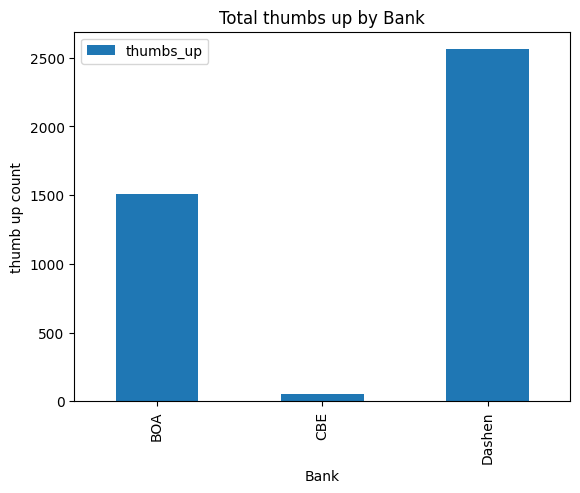

In [88]:
bank_thumbs.set_index('bank').plot(kind='bar')
plt.title('Total thumbs up by Bank')
plt.ylabel('thumb up count')
plt.xlabel('Bank')
plt.show()

In [90]:
score_dist = (
    df.groupby(['bank', 'score'])
    .size()
    .unstack(fill_value=0)
)
print(score_dist)

score    1  2  3  4   5
bank                   
BOA     50  7  4  5  36
CBE     19  3  5  9  60
Dashen  26  5  5  7  80


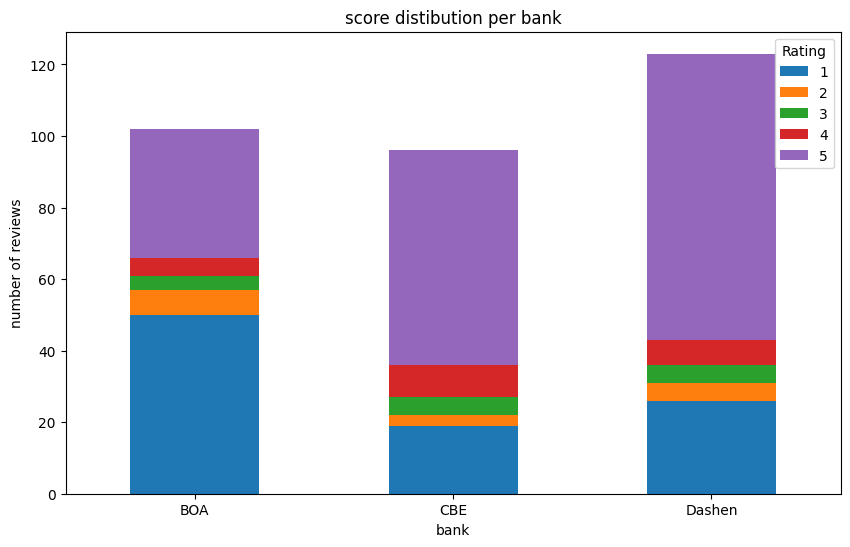

In [93]:
score_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
plt.title('score distibution per bank')
plt.xlabel('bank')
plt.ylabel('number of reviews')
plt.xticks(rotation=0)
plt.legend(title='Rating')
plt.show()